# Forward Radar: Balša Sekulić vs Najbliži Profil

Compare the league's best G+A forward — Balša Sekulić — against the most similar forwards using radar charts.

1. Compute per-90 stats for all outfield players
2. Percentile-rank each metric across all outfield players with ≥500 min
3. Use Euclidean distance to find the closest forwards
4. Draw radar charts comparing Sekulić vs his closest matches

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# ─── Path Configuration ────────────────────────────────────────────
LEAGUE = 'cg'  # 'cg' = Montenegro 1. CFL | 'srb' = Serbian SuperLiga

DATA_DIR       = Path('..') / 'data' / 'processed' / LEAGUE
FIGURES_DIR    = Path('..') / 'outputs' / LEAGUE / 'figures'
FINAL_DIR      = Path('..') / 'outputs' / LEAGUE / 'final_posts'
PLAYER_PHOTOS  = DATA_DIR / 'player_photos'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ─── Visual Constants ────────────────────────────────────────
BG_COLOR   = '#0a0a0a'
GOLD       = '#d4af37'
BLUE       = '#3498db'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#A0A0A0'
GRID_COLOR = '#1f2a3a'

In [10]:
# ─── Load Data ───────────────────────────────────────────────
season = pd.read_csv(DATA_DIR / 'player_season_statistics.csv')

# Filter: outfield players with enough minutes
MIN_MINUTES = 500
df = season[(season['position'].isin(['M', 'F', 'D'])) & (season['minutes_played'] >= MIN_MINUTES)].copy()
print(f'Outfield players with ≥{MIN_MINUTES} min: {len(df)}')

# ─── Compute per-90 metrics ──────────────────────────────────────
df['key_passes_per90']    = df['key_passes'] / df['minutes_played'] * 90
df['recoveries_per90']    = df['ball_recoveries'] / df['minutes_played'] * 90
df['interceptions_per90'] = df['interceptions'] / df['minutes_played'] * 90
df['dribbles_per90']      = df['dribbles_successful'] / df['minutes_played'] * 90
df['shots_per90']         = df['total_shots'] / df['minutes_played'] * 90
df['xG_per90']            = df['xG'] / df['minutes_played'] * 90
df['aerial_won_per90']    = df['aerial_won'] / df['minutes_played'] * 90

# Forward-focused radar metrics (8 stats)
RADAR_COLS = [
    'goals_per_90',
    'assists_per_90',
    'xG_per90',
    'shots_per90',
    'shot_accuracy',
    'avg_rating',
    'dribbles_per90',
    'aerial_won_per90',
]

RADAR_LABELS = [
    'Golovi/90',
    'Asistencije/90',
    'xG/90',
    'Šutevi/90',
    'Preciznost\nšuta (%)',
    'SofaScore\nrejting',
    'Driblinga/90',
    'Vazdušni\ndueli/90',
]

# ─── Percentile-rank each metric across all outfield players ─
base_cols = ['player_id', 'name', 'shortName', 'position', 'team_name', 'team_id', 'minutes_played']
keep_cols = list(dict.fromkeys(base_cols + RADAR_COLS))  # deduplicate, preserve order
df_pct = df[keep_cols].copy()

for col in RADAR_COLS:
    df_pct[col + '_pct'] = df_pct[col].rank(pct=True) * 100

PCT_COLS = [c + '_pct' for c in RADAR_COLS]

# Verify Sekulić is in the data
sekulic = df_pct[df_pct['name'] == 'Balša Sekulić']
print(f'\nBalša Sekulić:')
print(f'  Team: {sekulic.iloc[0]["team_name"]}, Rating: {sekulic.iloc[0]["avg_rating"]}')
print(f'  Minutes: {sekulic.iloc[0]["minutes_played"]:.0f}')
print(f'\nPercentile profile:')
for label, col in zip(RADAR_LABELS, PCT_COLS):
    print(f'  {label.replace(chr(10), " "):.<25} {sekulic.iloc[0][col]:.1f}')

Outfield players with ≥500 min: 172

Balša Sekulić:
  Team: FK Mornar Bar, Rating: 7.13
  Minutes: 1928

Percentile profile:
  Golovi/90................ 99.4
  Asistencije/90........... 95.3
  xG/90.................... 100.0
  Šutevi/90................ 100.0
  Preciznost šuta (%)...... 86.0
  SofaScore rejting........ 94.2
  Driblinga/90............. 54.7
  Vazdušni dueli/90........ 46.5


In [ ]:
# ─── Find most similar forwards ───────────────────────────
sekulic_id = sekulic.iloc[0]['player_id']
sekulic_vec = sekulic.iloc[0][PCT_COLS].values.astype(float)

# Candidates: forwards only, not Sekulić
candidates = df_pct[
    (df_pct['position'] == 'F') &
    (df_pct['player_id'] != sekulic_id)
].copy()

print(f'Candidate forwards: {len(candidates)}')

# Euclidean distance (lower = more similar)
candidates['distance'] = candidates[PCT_COLS].apply(
    lambda row: np.sqrt(np.sum((sekulic_vec - row.values.astype(float)) ** 2)), axis=1
)

candidates = candidates.sort_values('distance', ascending=True)

# Show top 10
print('\nTop 10 most similar forwards to Balša Sekulić:')
print('-' * 75)
for i, (_, row) in enumerate(candidates.head(10).iterrows()):
    print(f'  {i+1:>2}. {row["name"]:<25} ({row["team_name"]:<25}) '
          f'Dist: {row["distance"]:.1f}  Rating: {row["avg_rating"]}')

# Best match
match = candidates.iloc[0]
match_name = match['name']
print(f'\n→ Best match: {match_name} ({match["team_name"]})')
print(f'  Euclidean Distance: {match["distance"]:.1f}')
print(f'  Avg Rating: {match["avg_rating"]} (Sekulić: {sekulic.iloc[0]["avg_rating"]})')

Candidate forwards: 30

Top 10 most similar forwards to Balša Sekulić:
---------------------------------------------------------------------------
   1. Adnan Bašić               (OFK Petrovac             ) Dist: 38.4  Rating: 7.03
   2. Savo Arambašić            (OFK Petrovac             ) Dist: 51.5  Rating: 6.93
   3. Igor Poček                (FK Bokelj Kotor          ) Dist: 57.2  Rating: 6.93
   4. Balša Tošković            (FK Sutjeska Nikšić       ) Dist: 60.5  Rating: 6.84
   5. Vasilije Cavor            (FK Sutjeska Nikšić       ) Dist: 73.3  Rating: 6.92
   6. Žarko Korać               (FK Jedinstvo Bijelo Polje) Dist: 73.6  Rating: 7.01
   7. Đorđe Maksimović          (FK Jezero                ) Dist: 79.6  Rating: 6.99
   8. Vasko Kalezić             (FK Sutjeska Nikšić       ) Dist: 85.7  Rating: 6.86
   9. Ivan Bulatović            (FK Budućnost Podgorica   ) Dist: 89.7  Rating: 6.93
  10. Balša Radusinović         (FK Dečić Tuzi            ) Dist: 89.9  Rating: 6.8

→ B

In [12]:
# ─── Best player in each radar category (forwards only) ──────────────────────
print('Best forward per category (≥500 min):')
print('-' * 65)

fwds = df_pct[df_pct['position'] == 'F']
for label, col in zip(RADAR_LABELS, RADAR_COLS):
    best = fwds.loc[fwds[col].idxmax()]
    print(f'  {label.replace(chr(10), " "):.<25} {best["name"]:<22} ({best[col]:.2f})')

Best forward per category (≥500 min):
-----------------------------------------------------------------
  Golovi/90................ Đorđe Maksimović       (0.56)
  Asistencije/90........... Balša Tošković         (0.41)
  xG/90.................... Balša Sekulić          (0.52)
  Šutevi/90................ Balša Sekulić          (2.66)
  Preciznost šuta (%)...... Nemanja Nikolić        (100.00)
  SofaScore rejting........ Igor Vukcevic          (7.17)
  Driblinga/90............. Matija Rovčanin        (4.55)
  Vazdušni dueli/90........ Igor Vukcevic          (9.39)


#1 — Sekulić vs Adnan Bašić (dist: 38.4) → player_radar_sekulic.png


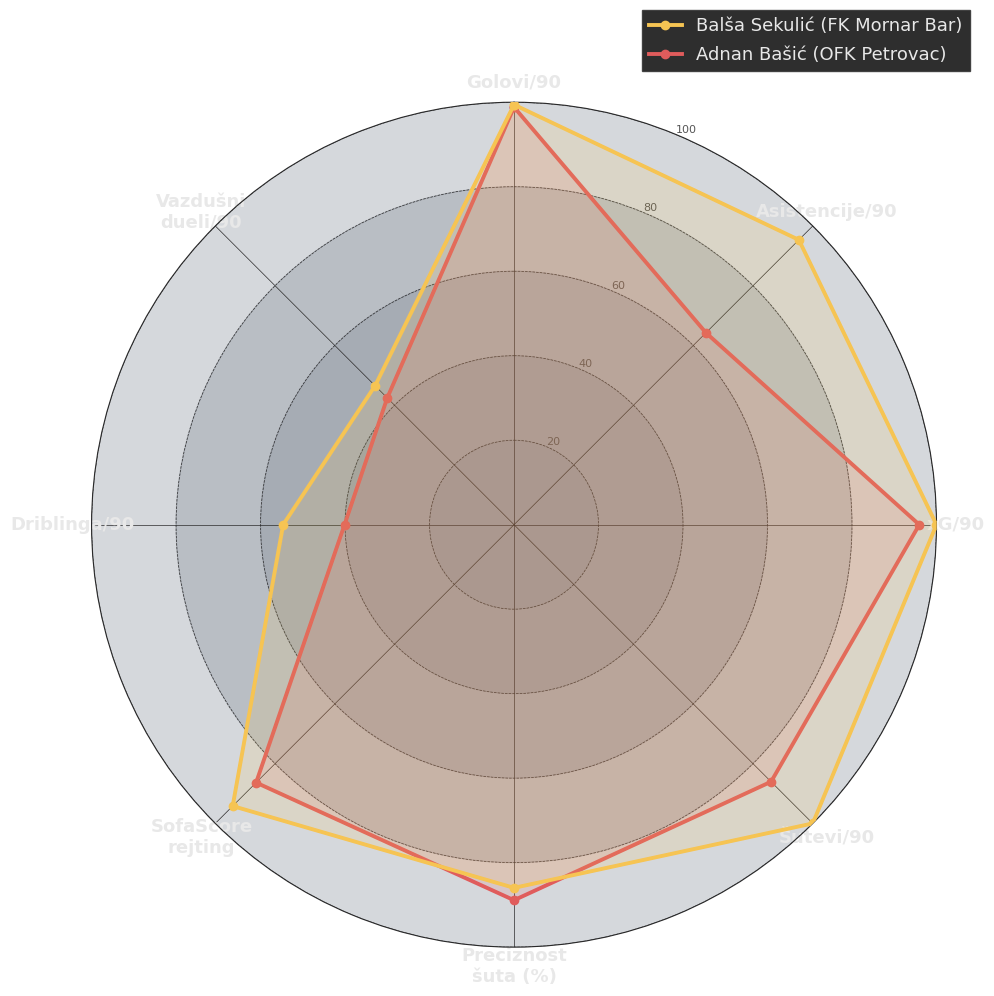

#2 — Sekulić vs Savo Arambašić (dist: 51.5) → player_radar_sekulic_2.png


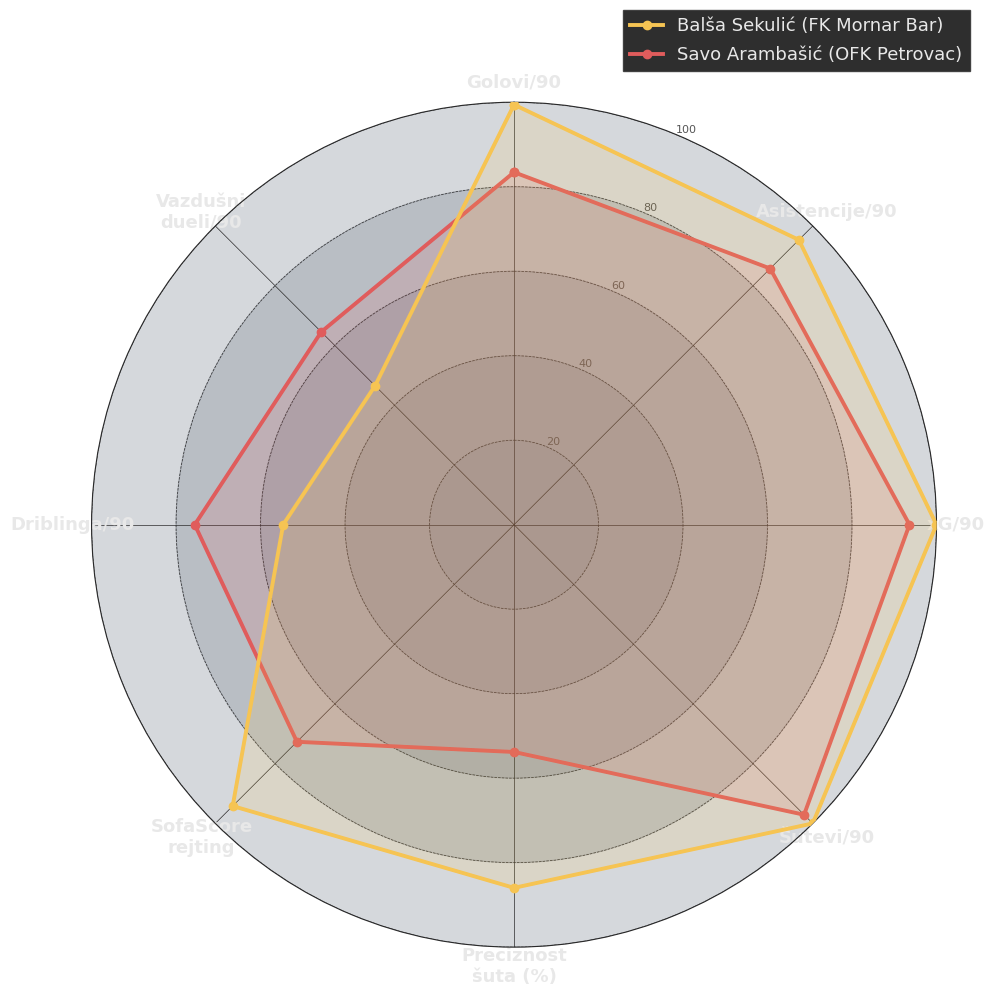

#3 — Sekulić vs Balša Tošković (dist: 60.5) → player_radar_sekulic_3.png


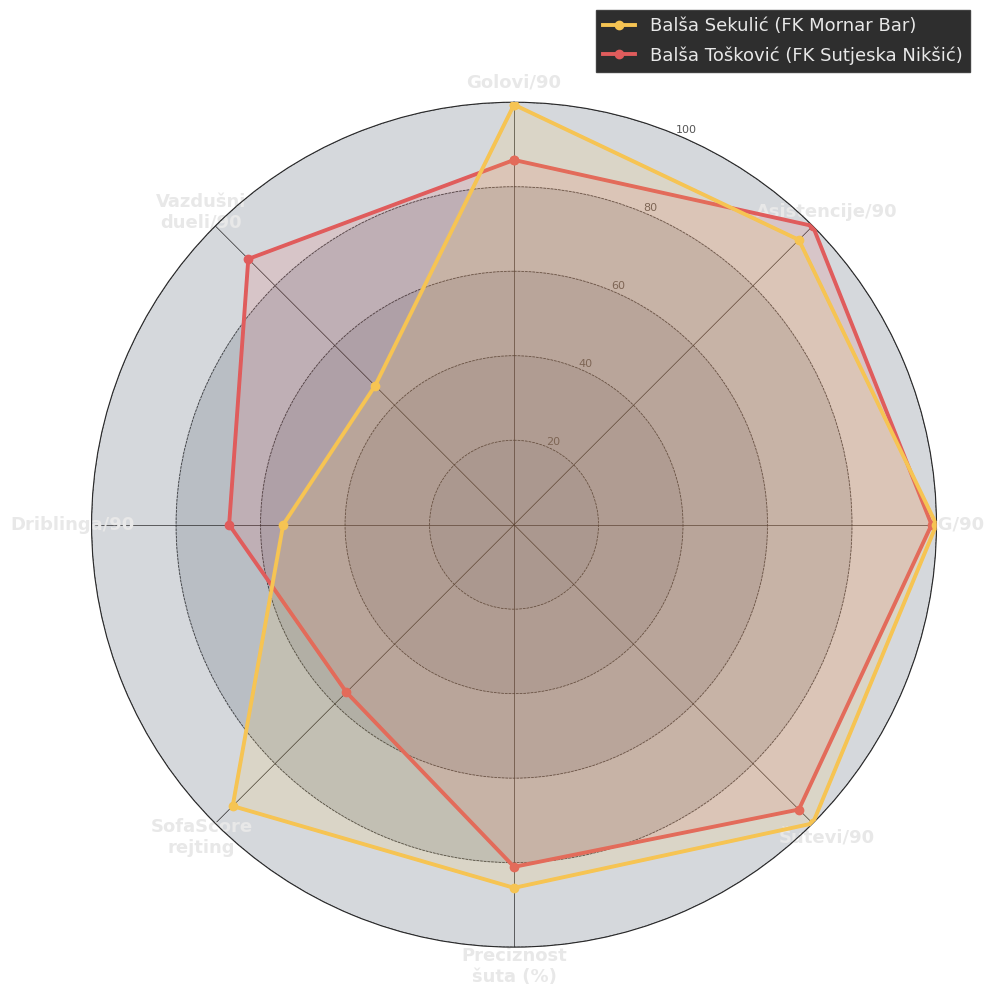

In [13]:
# ─── Radar Charts: Sekulić vs Top 3 closest forwards ────────────
# Using #1, #2, #4 (skipping #3)
N = len(RADAR_LABELS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

sekulic_vals = sekulic.iloc[0][PCT_COLS].values.astype(float).tolist()
sekulic_vals += sekulic_vals[:1]

# Colors that fit the dark/warm theme
SEKULIC_COLOR = '#f6c453'   # warm gold
MATCH_COLOR   = '#e05c5c'   # muted red

top3 = [candidates.iloc[0], candidates.iloc[1], candidates.iloc[3]]

for rank, opponent in enumerate(top3, start=1):
    opp_vals = opponent[PCT_COLS].values.astype(float).tolist()
    opp_vals += opp_vals[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True), dpi=100)
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Concentric ring fills
    ring_values = [20, 40, 60, 80, 100]
    ring_alphas = [0.06, 0.09, 0.12, 0.15, 0.18]
    for rv, ra in zip(ring_values, ring_alphas):
        ax.fill(np.linspace(0, 2 * np.pi, 200), [rv] * 200, color='#1a283d', alpha=ra, zorder=0)

    # Plot Sekulić (on top)
    ax.plot(angles, sekulic_vals, 'o-', linewidth=2.8, color=SEKULIC_COLOR, markersize=6, zorder=6,
            label=f'Balša Sekulić ({sekulic.iloc[0]["team_name"]})')
    ax.fill(angles, sekulic_vals, alpha=0.15, color=SEKULIC_COLOR, zorder=5)

    # Plot opponent (behind)
    ax.plot(angles, opp_vals, 'o-', linewidth=2.8, color=MATCH_COLOR, markersize=6, zorder=4,
            label=f'{opponent["name"]} ({opponent["team_name"]})')
    ax.fill(angles, opp_vals, alpha=0.15, color=MATCH_COLOR, zorder=3)

    # Stat labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=13, color='#e8e8e8', fontweight='bold')

    # Radial grid
    ax.set_ylim(0, 100)
    ax.set_yticks(ring_values)
    ax.set_yticklabels([str(v) for v in ring_values], fontsize=8, color='#555555')
    ax.yaxis.grid(True, color='#2a2a2a', linewidth=0.5, linestyle='--')
    ax.xaxis.grid(True, color='#2a2a2a', linewidth=0.5)
    ax.spines['polar'].set_color('#2a2a2a')

    # Legend — top right
    legend = ax.legend(
        loc='upper right', bbox_to_anchor=(1.05, 1.12),
        fontsize=13, fancybox=False, edgecolor='#333333',
        facecolor='#0a0a0a', labelcolor='#e8e8e8', framealpha=0.85,
        handlelength=1.8, handletextpad=0.8, labelspacing=0.6
    )
    legend.get_frame().set_linewidth(1.0)

    plt.tight_layout()
    suffix = '' if rank == 1 else f'_{rank}'
    save_path = FIGURES_DIR / f'player_radar_sekulic{suffix}.png'
    fig.savefig(save_path, dpi=100, transparent=True, bbox_inches='tight', pad_inches=0.02)
    print(f'#{rank} — Sekulić vs {opponent["name"]} (dist: {opponent["distance"]:.1f}) → {save_path.name}')
    plt.show()

Saved: ..\outputs\final_posts\player_radar_sekulic_post.png


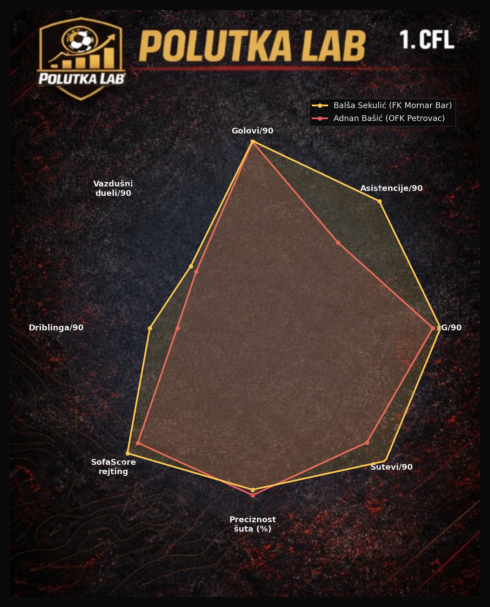

Saved: ..\outputs\final_posts\player_radar_sekulic_2_post.png


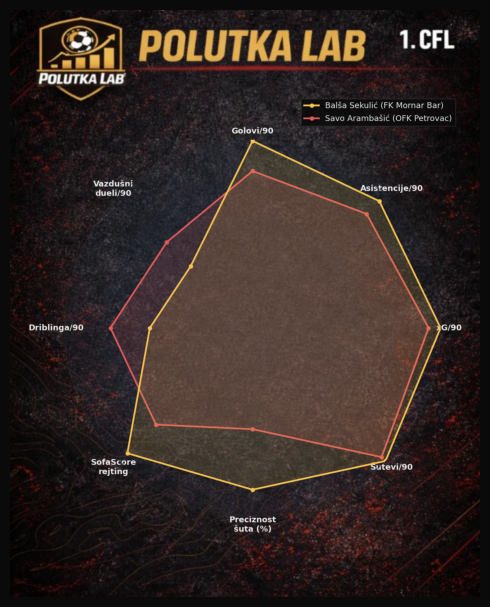

Saved: ..\outputs\final_posts\player_radar_sekulic_3_post.png


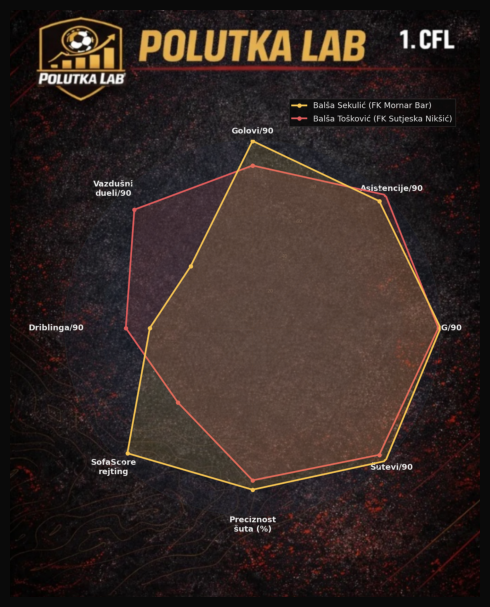

In [14]:
# ─── Instagram Post Composition (all 3) ─────────────────────
BACKGROUND_PATH = Path('..') / 'assets' / 'background.png'
INSTAGRAM_SIZE = (1080, 1350)

for rank in range(1, 4):
    suffix = '' if rank == 1 else f'_{rank}'
    chart_path = FIGURES_DIR / f'player_radar_sekulic{suffix}.png'

    if BACKGROUND_PATH.exists():
        background = Image.open(BACKGROUND_PATH).convert('RGBA')
        if background.size != INSTAGRAM_SIZE:
            background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
    else:
        background = Image.new('RGBA', INSTAGRAM_SIZE, BG_COLOR)

    chart = Image.open(chart_path).convert('RGBA')

    chart_w = 1000
    chart_h = int(chart.height * (chart_w / chart.width))
    chart = chart.resize((chart_w, chart_h), Image.Resampling.LANCZOS)

    x_offset = (INSTAGRAM_SIZE[0] - chart_w) // 2
    y_offset = (INSTAGRAM_SIZE[1] - chart_h) // 2 + 30

    background.alpha_composite(chart, (x_offset, y_offset))

    final_path = FINAL_DIR / f'player_radar_sekulic{suffix}_post.png'
    background.convert('RGB').save(final_path, quality=95)
    print(f'Saved: {final_path}')

    # Preview
    fig_p, ax_p = plt.subplots(figsize=(5, 6.25))
    ax_p.imshow(background)
    ax_p.axis('off')
    fig_p.patch.set_facecolor(BG_COLOR)
    plt.tight_layout()
    plt.show()